# Visualizing Elastic-Net Hyperparameter Tuning
This notebook demonstrates how to train an Elastic-Net linear model and visualize the hyperparameter tuning process using `GridSearchCV` and 5-fold cross-validation.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

## 1. Load and Prepare the Data
First, we load the California Housing dataset and split it into features (X) and the target variable (y). The target is `MedHouseVal` (Median House Value).

In [9]:
file_path = 'california_housing.csv'
housing_df = pd.read_csv(file_path)

X = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Understanding the Components
### Pipeline
We use a `Pipeline` to chain together multiple steps. This ensures that the same steps are applied to our training and testing data consistently.
### StandardScaler
StandardScaler standardizes features by removing the mean and scaling to unit variance. This is important for regularization methods like Elastic-Net.
### Elastic-Net
Elastic-Net is a linear regression model that combines L1 and L2 regularization. It has two main hyperparameters:
- `alpha`: The punishment coefficient. It controls the overall strength of the regularization.
- `l1_ratio`: This determines the mix of L1 and L2 penalties. An `l1_ratio` of 1 is equivalent to a Lasso regression, while 0 is a Ridge regression.

## 3. Hyperparameter Tuning with GridSearchCV
### 5-Fold Cross-Validation
`GridSearchCV` uses cross-validation to evaluate each combination of hyperparameters. For 5-fold cross-validation, the training data is split into 5 equal 'folds'. The model is then trained on 4 of the folds and evaluated on the 5th (the 'hold-out' fold). This process is repeated 5 times, with each fold serving as the hold-out set once. The 5 evaluation scores are then averaged to give a more robust measure of the model's performance for that set of hyperparameters.

### Grid Search
We define a `param_grid` which is a dictionary containing the hyperparameters and the values we want to test. `GridSearchCV` will then exhaustively test every possible combination using 5-fold cross-validation.

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic_net', ElasticNet(max_iter=10000))
])

param_grid = {
    'elastic_net__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'elastic_net__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, 
                           scoring='neg_mean_squared_error', 
                           verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'elastic_net__alpha': [0.001, 0.01, ...], 'elastic_net__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [11]:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score (negative MSE): ", grid_search.best_score_)

Best parameters found:  {'elastic_net__alpha': 0.001, 'elastic_net__l1_ratio': 1.0}
Best cross-validation score (negative MSE):  -0.5192614509760378


## 4. Visualizing the Grid Search Results
Now we'll visualize the results of our grid search. The following heatmap shows the performance (Negative Mean Squared Error) for each combination of `alpha` and `l1_ratio`. Darker colors indicate better performance (a less negative MSE). This allows us to see how the model's performance changes as we adjust the hyperparameters.

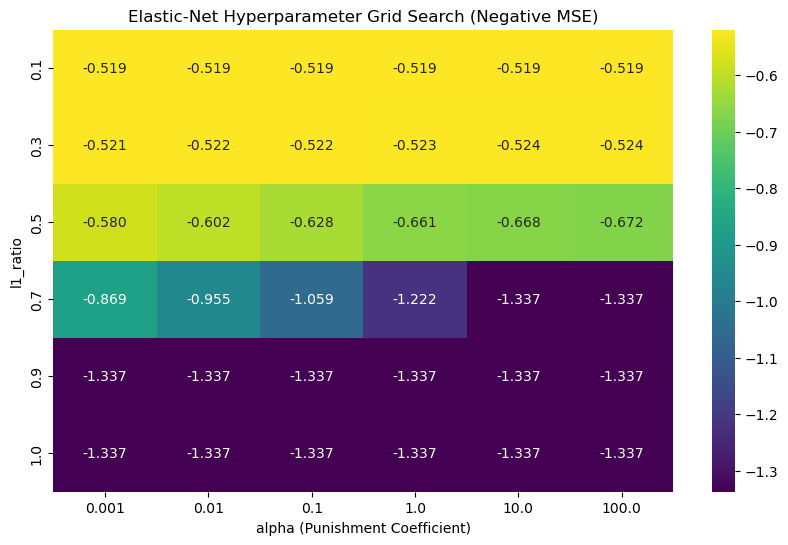

In [12]:
results = pd.DataFrame(grid_search.cv_results_)
scores = np.array(results.mean_test_score).reshape(len(param_grid['elastic_net__l1_ratio']), len(param_grid['elastic_net__alpha']))

plt.figure(figsize=(10, 6))
sns.heatmap(scores, annot=True, fmt='.3f', 
            xticklabels=param_grid['elastic_net__alpha'], 
            yticklabels=param_grid['elastic_net__l1_ratio'],
            cmap='viridis')
plt.xlabel('alpha (Punishment Coefficient)')
plt.ylabel('l1_ratio')
plt.title('Elastic-Net Hyperparameter Grid Search (Negative MSE)')
plt.show()

## 5. Final Evaluation on the Test Set
Finally, we evaluate the best model (found by GridSearchCV) on the test set to get a final, unbiased estimate of its performance.

In [13]:
y_pred = grid_search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error on test set: {rmse}")

Root Mean Squared Error on test set: 0.7446417662764214
